# Per-Image NRE Posteriors: Uncalibrated vs. Calibrated

This notebook uses the trained NRE to produce per-image posteriors over ($w_0$, $\Omega_m$) for 5 test lenses that share the same true cosmology. The NRE log-ratio is used as a likelihood surrogate in the MCMC sampler. Posteriors are computed twice, once using the raw NRE output and once with calibration correction applied to the summed log-ratio. 

In [1]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
import pickle
import corner
import pandas as pd
from scipy.stats import gaussian_kde
import tensorflow as tf

2026-07-17 03:12:57.444959: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-17 03:13:01.608242: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# define your plot style

best_style = {
    "font.family": "sans-serif",
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Heros",
    "mathtext.bf": "TeX Gyre Heros:bold",
    "mathtext.sf": "TeX Gyre Heros",
    "mathtext.it": "TeX Gyre Heros:italic",
    "mathtext.tt": "TeX Gyre Heros",
    "mathtext.cal": "TeX Gyre Heros",
    "mathtext.default": "regular",
    "figure.figsize": (10.0, 10.0),
    "font.size": 26,
    "axes.labelsize": "medium",
    "axes.unicode_minus": False,
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
    "legend.fontsize": "small",
    "legend.handlelength": 1.5,
    "legend.borderpad": 0.5,
    "xtick.direction": "in",
    "xtick.major.size": 12,
    "xtick.minor.size": 6,
    "xtick.major.pad": 6,
    "xtick.top": True,
    "xtick.major.top": True,
    "xtick.major.bottom": True,
    "xtick.minor.top": True,
    "xtick.minor.bottom": True,
    "xtick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.major.size": 12,
    "ytick.minor.size": 6.0,
    "ytick.right": True,
    "ytick.major.left": True,
    "ytick.major.right": True,
    "ytick.minor.left": True,
    "ytick.minor.right": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.8,
    "grid.linestyle": ":",
    "axes.linewidth": 2,
    "savefig.transparent": False,
}
plt.style.use(best_style)
cols = ["#5790fc", "#f89c20", "#e42536", "#964a8b", "#9c9ca1", "#7a21dd"]
#set cols as the matplotlib default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cols)

In [3]:
# load the model
model_name = "entire_region_narrowprior"
model_path = '/deepskieslab/stronglensing/hsbi/models/'
model = tf.keras.models.load_model(model_path + model_name + '.keras')

2026-07-17 03:13:14.862318: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-17 03:13:15.798477: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-17 03:13:15.798958: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [4]:
# load the data
datadir = "region2_narrowprior"

image_dir = f'/deepskieslab/stronglensing/hsbi/datasets/test_data/{datadir}/data_0'
images = np.load(image_dir + '/CONFIGURATION_1_images.npy', allow_pickle=True)
metadata = pd.read_csv(image_dir + '/CONFIGURATION_1_metadata.csv')

In [29]:
figpath = f'/home/jarugula/nre_wom/proj_cosmo_nre/src/scripts/evaluate/mcmc/plots/'

In [5]:
w_column_name = "w0-g" 
om_column_name = 'Om0-g'
zl_column_name = 'PLANE_1-REDSHIFT-g'
zs_column_name = 'PLANE_2-REDSHIFT-g'
v_column_name = 'PLANE_1-OBJECT_1-MASS_PROFILE_1-sigma_v-g'

In [6]:
n_images = 5
images = images[0: n_images]
metadata = metadata[0: n_images]
images = np.einsum('lkij->lijk', images)
print(images.shape)

aparms = metadata[[zl_column_name,zs_column_name,v_column_name]].to_numpy().astype(np.float32)

(5, 32, 32, 1)


In [7]:
# preprocess the images 
edge_size = images.shape[1]
images = edge_size * edge_size * (images / np.sum(images, axis=(1, 2), keepdims=True))
images = images.reshape(images.shape[0], -1)
images = images.reshape(images.shape[0], edge_size, edge_size, 1)

In [8]:
# return true values
true_w = metadata[w_column_name].unique()[0]
true_om = metadata[om_column_name].unique()[0]

print(true_w, true_om)

-0.9895467391672544 0.3289012922760826


## MCMC

In [9]:
# Calibration applies a correction (alpha * sum(logr) + beta) derived from 
# a held-out calibration set to correct for any bias in the raw NRE ratio estimates.
def get_logr_mcmc(model, images, aparam, sample_theta):
    ''''
    Function to predict the log likelihood-to-evidence ratio (logr) of all the test data at a time

    Input:
    model: The trained model 
    images: test images
    sample_theta: a list of theta values to compute logr for

    Output:
    log r 
    '''
    theta_array = np.array([sample_theta]*images.shape[0])
    output = model.predict([images, aparam, theta_array], verbose=0).flatten()
    return output

def log_prior(theta, w_low=-1.5, w_high=-0.5, om_low=0.1, om_high=0.5):
    """
    prior for w, om
    """
    w, om = theta
    if w_low < w < w_high and om_low < om < om_high:
        return 0.0
    return -np.inf

def log_likelihood(theta, data, aparam, w_low, w_high, om_low, om_high, model, calibrate):
    """
    Calculate the log likelihood + log prior
    """
    lp = log_prior(theta, w_low, w_high, om_low, om_high)
    if not np.isfinite(lp):
        return -np.inf
    logr_array = get_logr_mcmc(model, data, aparam, theta)
    if calibrate:
        alpha = 0.175255
        beta = 0.11896
        ll = alpha*np.sum(logr_array) + beta
    else:
        ll = np.sum(logr_array)
    return lp + ll

In [10]:
initial_w=-1.0
initial_om=0.3
walkers=5
nsteps=1000
nburn=200

ommin = 0.1
ommax = 0.9
wmin = -1.8
wmax = -0.4

### Without calibration

In [11]:
# pos = np.array([initial_w, initial_om]) + np.array([initial_w, initial_om]) * 1e-3 * np.random.randn(walkers, 2)
# nwalkers, ndim = pos.shape

# calibrate = False
# flat_samples_list = []

# for i in range(n_images):
#     data = images[i: i+1]
#     aparam = aparms[i: i+1]

#     sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(data, aparam, wmin, wmax, ommin, ommax, model, calibrate))
#     print("Running first burn-in...")
#     pos, lp, _ = sampler.run_mcmc(pos, nburn, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     print("Running production...")
#     pos = pos[np.argmax(lp)] + 1e-4 * np.random.randn(nwalkers, ndim)
#     sampler.reset()
#     pos, lp, _ = sampler.run_mcmc(pos, nsteps, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     flat_samples = sampler.get_chain(discard=int(nsteps / 4), flat=True)
#     flat_samples_list.append(flat_samples)

# flat_samples_nocalibrate = np.vstack(flat_samples_list)

In [12]:
# # save the flat samples without calibration
# with open('flat_samples_5images_nocalibrate.pkl', 'wb') as f:
#     pickle.dump(flat_samples_nocalibrate, f)

### With Calibration

In [13]:
# calibrate = True
# flat_samples_list_calibrate = []
# pos = np.array([initial_w, initial_om]) + np.array([initial_w, initial_om]) * 1e-3 * np.random.randn(walkers, 2)
# nwalkers, ndim = pos.shape

# for i in range(n_images):
#     data = images[i: i+1]
#     aparam = aparms[i: i+1]

#     sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(data, aparam, wmin, wmax, ommin, ommax, model, calibrate))
#     print("Running first burn-in...")
#     pos, lp, _ = sampler.run_mcmc(pos, nburn, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     print("Running production...")
#     pos = pos[np.argmax(lp)] + 1e-4 * np.random.randn(nwalkers, ndim)
#     sampler.reset()
#     pos, lp, _ = sampler.run_mcmc(pos, nsteps, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     flat_samples = sampler.get_chain(discard=int(nsteps / 4), flat=True)
#     flat_samples_list_calibrate.append(flat_samples)

# flat_samples_calibrate = np.vstack(flat_samples_list_calibrate)

In [14]:
# # save the flat samples with calibration
# with open('flat_samples_5images_calibrate.pkl', 'wb') as f:
#     pickle.dump(flat_samples_calibrate, f)

### Plot the posteriors 

In [15]:
# MCMC runs are pre-computed and saved; load results here to avoid re-running the sampler.
with open('flat_samples_5images_nocalibrate.pkl', 'rb') as f:
    flat_samples_nocalibrate = pickle.load(f)

with open('flat_samples_5images_calibrate.pkl', 'rb') as f:
    flat_samples_calibrate = pickle.load(f)

In [16]:
flat_samples_nocalibrate.shape

(18750, 2)

In [17]:
# Samples from all images are stacked in one array; split back into per-image lists for plotting.
n_samples_per_image = flat_samples_nocalibrate.shape[0] // n_images  # 3750
flat_samples_list = np.split(flat_samples_nocalibrate, n_images)

In [18]:
n_samples_per_image = flat_samples_calibrate.shape[0] // n_images  # 3750
flat_samples_list_calibrate = np.split(flat_samples_calibrate, n_images)

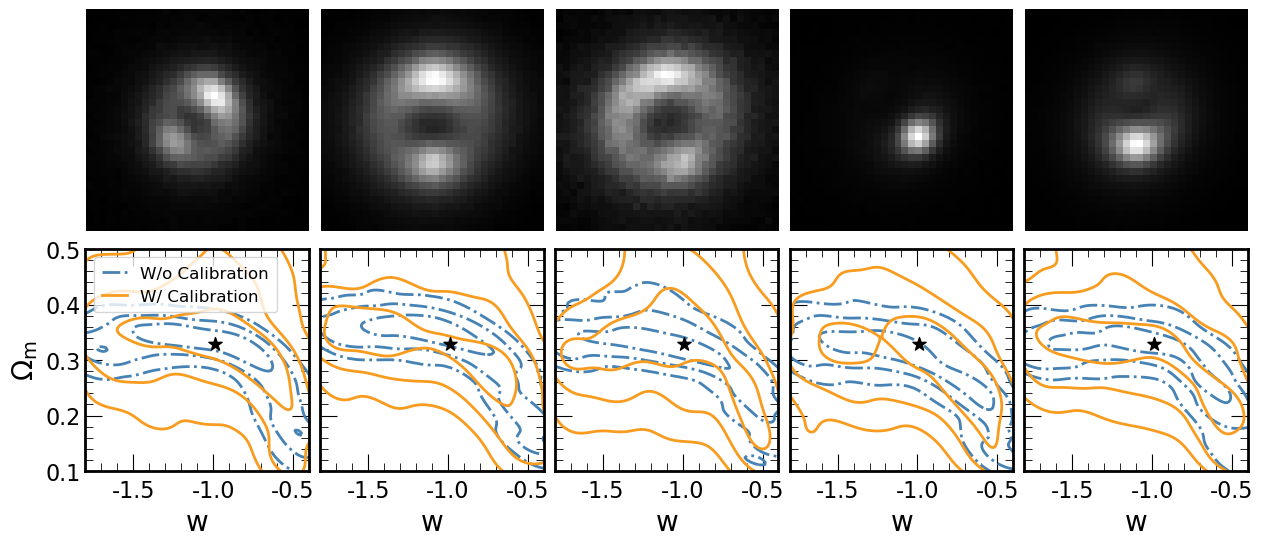

In [30]:
# Row 0: lens images. Row 1: overlaid posterior contours (uncalibrated vs calibrated).
# KDE is used to estimate the posterior density from MCMC samples; get_levels converts
# the KDE surface to contour levels corresponding to the 1, 2, 3-sigma credible regions.
# True (w, Om) is marked with a star on every panel.
x_min = -1.8
x_max = -0.4
y_min = 0.1
y_max = 0.5

def get_levels(Z, sigmas=[1,2,3]):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for s in sigmas:
        frac = 1 - np.exp(-0.5 * s**2)
        idx = np.searchsorted(cumsum, frac)
        levels.append(Z_sorted[idx])
    return levels

fig, axes = plt.subplots(2, n_images, figsize=(15, 6))
for i in range(n_images):
    axes[0, i].imshow(images[i, :, :, 0], cmap='gray')
    axes[0, i].axis('off')

    nbins = 100
    xgrid = np.linspace(x_min, x_max, nbins)
    ygrid = np.linspace(y_min, y_max, nbins)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Without calibration
    flat_samples = flat_samples_list[i]
    kde = gaussian_kde(np.vstack([flat_samples[:, 0], flat_samples[:, 1]]))
    Z1 = kde(positions).reshape(X.shape)
    levels1 = np.sort(get_levels(Z1, [1, 2, 3]))
    axes[1, i].contour(X, Y, Z1, levels=levels1, colors='steelblue', linewidths=2, linestyles='-.')

    # With calibration
    flat_samples_cal = flat_samples_list_calibrate[i]
    kde_cal = gaussian_kde(np.vstack([flat_samples_cal[:, 0], flat_samples_cal[:, 1]]))
    Z2 = kde_cal(positions).reshape(X.shape)
    levels2 = np.sort(get_levels(Z2, [1, 2, 3]))
    axes[1, i].contour(X, Y, Z2, levels=levels2, colors=cols[1], linewidths=2, linestyles='-')

    axes[1, i].scatter(true_w, true_om, color="k", s=100, marker="*", zorder=5)
    axes[1, i].set_xlabel(r"$w$", fontsize=20)
    axes[1, i].set_xlim(x_min, x_max)
    axes[1, i].set_ylim(y_min, y_max)
    axes[1, i].tick_params(axis='both', labelsize=16)

    if i == 0:
        axes[1, i].set_ylabel(r"$\Omega_m$", fontsize=20)
    else:
        axes[1, i].set_yticklabels([])
        axes[1, i].set_ylabel('')

# Legend on first panel
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', linewidth=2, linestyle='-.', label='W/o Calibration'),
    Line2D([0], [0], color=cols[1], linewidth=2, linestyle='-', label='W/ Calibration'),
]
axes[1, 0].legend(handles=legend_elements, fontsize=12, loc='upper left')

plt.subplots_adjust(wspace=0.05, hspace=0.08)
# plt.show()
plt.savefig(figpath + 'image_posteriors_5images.pdf', dpi=300, bbox_inches='tight')
